# Intel Image Classification using Neural Networks, CNNs and Transfer Learning
### Delivered by
- Mohamed Abdelmohsen Soliman


#### Dataset:

[Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)

---

## **Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tqdm import tqdm # if you are going to use tqdm, make sure to import it this way, otherwise it will not render properly in Github Repos
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import TensorDataset, DataLoader, Subset, random_split
from torchvision import datasets, transforms


## **Python Version Used**

In [2]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


### **Libraries versions**
I have attached the **requirements.txt** in the repo as well

In [3]:
## Libraries version check
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Pandas version: 2.2.2
Numpy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
PyTorch version: 2.10.0+cu128
Scikit-learn version: 1.6.1
torchvision version: 0.25.0+cu128


### To make a model reproducible, we must fix the seed of any randomness!
##### Additionally, we save each model with its best weights to be able to reload it anytime from its **.pth file**.
I am doing that after traininig of each model below.

In [4]:
import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

### Reading the Dataset and view it

## 📂 Dataset: Intel Image Classification

* **Dataset Domain:** Natural landscapes and urban scenes inot 6 classes (Buildings, Forest, Glacier, Mountain, Sea, Street).
<!-- * **Model Domain:** High overlap with **ImageNet** (used in Task 3), as it contains similar outdoor and architectural categories. -->

**Data Split & Structure**
 - The data is already split from kaggle into
* **`seg_train`**: ~14,000 labeled images for training all models.
* **`seg_test`**: ~3,000 labeled images for validation and metric reporting (Acc, Recall, etc.).
* **`seg_pred`**: ~7,000 unlabeled images (Optional for final blind testing, wont be used here).

**Tricks That i implemented**

* **Lazy Loading:** Implemented via DataLoader from **torch**
---

#### Downloading the Dataset directly from kaggle using **kagglehub**

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [6]:
# path = 'Datasets/IntelData'
TrainDataPath = f"{path}/seg_train/seg_train"
TestDataPath = f"{path}/seg_test/seg_test"

## **Let us visualize the data and Check data imbalance**

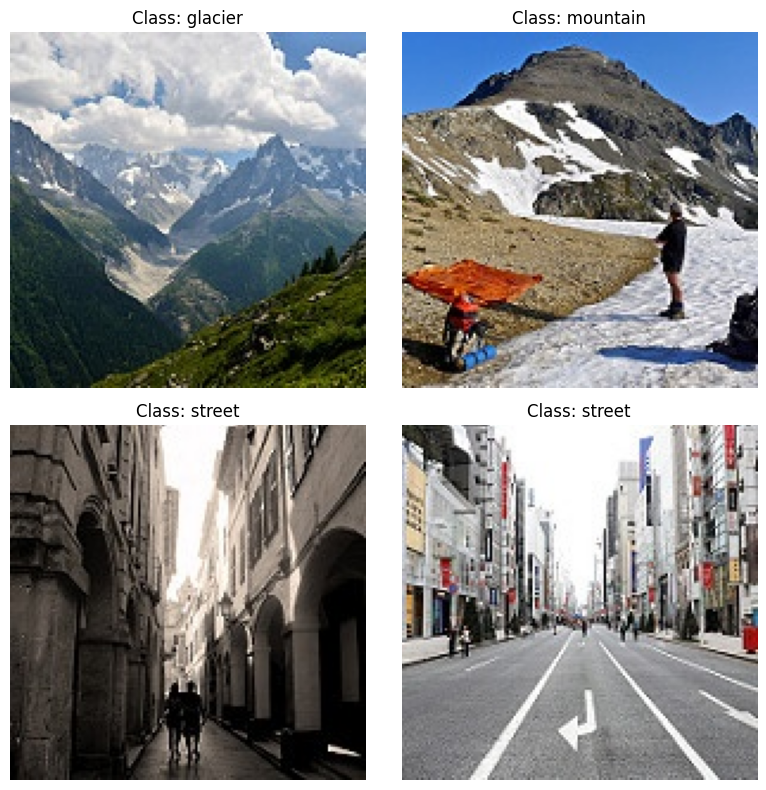

In [7]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# here we get all class names from folder names
classes = os.listdir(TrainDataPath)

plt.figure(figsize=(8, 8))

for i in range(4):
    # first we pick a random class
    random_class = random.choice(classes)
    class_path = os.path.join(TrainDataPath, random_class)

    # the we pick a random image from that class
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

#load it and plot
    img = Image.open(img_path)
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {random_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Checking the data balance

mountain: 2512 images
glacier: 2404 images
street: 2382 images
sea: 2274 images
forest: 2271 images
buildings: 2191 images


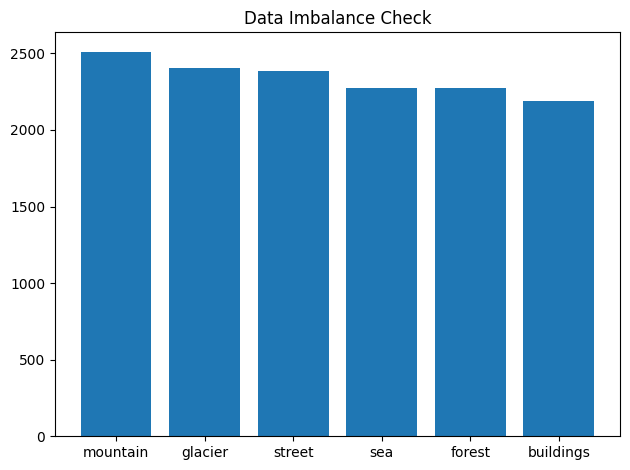

In [8]:
import os

counts = {}
for label in os.listdir(TrainDataPath):
    class_path = os.path.join(TrainDataPath, label) # we check if the path is a directory to avoid any issues with hidden files or non-directory items
    if os.path.isdir(class_path):
        counts[label] = len(os.listdir(class_path)) # we count the number of images in each class by listing the files in the class directory and getting their length

counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)) # here we sort the counts in descending order

for label, count in counts.items():
    print(f"{label}: {count} images")

fig, ax = plt.subplots()
ax.bar(counts.keys(), counts.values())
ax.set_title("Data Imbalance Check")
plt.tight_layout()
plt.show()

#### Now we have ~17K Images with 3 Color Channels (RGB) to predict 6 different classes:

* **Buildings** - 0
* **Forest** - 1
* **Glacier** - 2
* **Mountain** - 3
* **Sea** - 4
* **Street** - 5

---

### chooing the gpu as the target device to fasten teh learning process

In [9]:
device = torch.device("cuda")

### The data is perfectly balanced. We are good to go to start loading the data & learning

## **Data Preprocessing & Augmentation**

In [10]:

transform = transforms.Compose([ # here we are transforming the images using flipping, rotation, resizing and converting to tensor. This helps in data augmentation and preparing the images for training.
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((150, 150)), #  we resize all images to a consistent size (150x150) to ensure uniformity
    transforms.ToTensor()
])

# the lazy Loading part via ImageFolder from torch
full_train_dataset = datasets.ImageFolder(root=TrainDataPath, transform=transform)
test_dataset = datasets.ImageFolder(root=TestDataPath, transform=transform)

# taking 100% of the indices randomly since the dataset is already small
num_train = len(full_train_dataset)
indices = list(range(num_train))
np.random.shuffle(indices)
train_idx = indices[:] # we take all indices since the dataset is already small, but we shuffle them to ensure randomness

train_subset = Subset(full_train_dataset, train_idx)

train_dataset, val_dataset = random_split(train_subset, [0.9, 0.1]) # we only take 10% for the val set

# This is the Dataloaders for training, test, and val all with batch size of 32 and shuffling only the training set.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Using {len(train_dataset)} images for training.")
print(f"Using {len(val_dataset)} images for training.")

Using 12631 images for training.
Using 1403 images for training.


## **Simple MLP**
##### Used a simple MLP with 3 fullyconnected layers and a relu activation function for hidden layers. Additionally, CrossEntropy was used to ensure Softmax behavior

In [ ]:
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # flatten: 150*150*3 = 67500
        self.fc1 = nn.Linear(150 * 150 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 6) # 6 Output classes which are : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

    def forward(self, x):
        x = x.view(x.size(0), -1) # flatten the input tensor to (batch_size, 67500) for the fully connected layers
        x = F.relu(self.fc1(x)) # relu for the next two layers
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_mlp = SimpleMLP()

In [ ]:
model_mlp.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)

### Ensuring that gpu is selected

In [11]:
print(f"Using device: {device}")

Using device: cuda


### Sanity Check Function, will be called to ensure the Golden Rules of learning

##### We are letting the model memorize the subset to check if our piepline is safe to go with

In [ ]:
from torch.utils.data import DataLoader, Subset

def SanityCheck(sanityModel, epochs): # a sanity check func that takes the model, and number of epochs as arguments
    # picking a tiny subset (100 samples) from the dataset
    sanity_indices = range(100)
    sanity_subset = Subset(train_dataset, sanity_indices)
    sanity_loader = DataLoader(sanity_subset, batch_size=20, shuffle=True)

    print("=" * 60)
    print("SANITY CHECK: Overfitting on 100 Intel Images")
    print("=" * 60)

    sanity_model = sanityModel

    sanity_optimizer = torch.optim.Adam(sanity_model.parameters(), lr=0.0008) # using a lr of 0.0008 for the sanity check to ensure better convergence on the small subset
    sanity_criterion = nn.CrossEntropyLoss() # same loss function for the sanity check (Softmax)

    for epoch in range(epochs): # run for the number of params-epochs
        sanity_model.train()
        running_loss = 0.0

        for images, labels in sanity_loader:
            images, labels = images.to(device), labels.to(device)

            sanity_optimizer.zero_grad()
            outputs = sanity_model(images)
            loss = sanity_criterion(outputs, labels)
            loss.backward()
            sanity_optimizer.step()

            running_loss += loss.item()

        # Check progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            sanity_model.eval()
            # lists to store predictions and labels for accuracy calculation
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for images, labels in sanity_loader:
                    images = images.to(device)
                    logits = sanity_model(images)
                    preds = torch.argmax(logits, dim=1)

                    # appending predictions and labels to the lists for accuracy calculation
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.numpy())

            acc = accuracy_score(all_labels, all_preds)
            print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(sanity_loader):.4f} | Acc: {acc:.4f}")

            if acc == 1.0:
                print("\n✅ SUCCESS: Model memorized the subset. The pipeline is healthy!")
                break

### Here we are running the sanity check for the MLP

In [ ]:
SanityCheck(SimpleMLP().to(device), 200)

SANITY CHECK: Overfitting on 100 Intel Images
Epoch 10 | Loss: 1.4382 | Acc: 0.4600
Epoch 20 | Loss: 1.0456 | Acc: 0.7100
Epoch 30 | Loss: 0.8100 | Acc: 0.6300
Epoch 40 | Loss: 0.6785 | Acc: 0.8000
Epoch 50 | Loss: 0.5764 | Acc: 0.7800
Epoch 60 | Loss: 0.4044 | Acc: 0.7500
Epoch 70 | Loss: 0.4605 | Acc: 0.8000
Epoch 80 | Loss: 0.2588 | Acc: 0.9400
Epoch 90 | Loss: 0.2408 | Acc: 0.9900
Epoch 100 | Loss: 0.1844 | Acc: 0.9600
Epoch 110 | Loss: 0.0855 | Acc: 0.9900
Epoch 120 | Loss: 0.0364 | Acc: 0.9900
Epoch 130 | Loss: 0.0366 | Acc: 0.9900
Epoch 140 | Loss: 0.0599 | Acc: 0.9900
Epoch 150 | Loss: 0.0066 | Acc: 1.0000

✅ SUCCESS: Model memorized the subset. The pipeline is healthy!


### The train function is a standard training loop for a PyTorch model. It takes the model, optimizer, loss criterion, number of epochs, device, and data loaders for training and validation as inputs. It trains the model for the specified number of epochs while keeping track of training and validation loss and accuracy. The function also uses tqdm to display a progress bar during training (but needs to import it as from tqdm import tqdm).

In [12]:
def train(model, optimizer, criterion, epochs, device, train_loader, val_loader):

  # Dictionary to store metrics for plotting later
  history = {
      'train_loss': [], 'train_acc': [],
      'val_loss': [], 'val_acc': []
  }

  for epoch in range(epochs):

      model.train()
      running_loss = 0.0
      correct = 0
      total = 0

      # this is the tqdm progress bar
      loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)

      for images, labels in loop: # looping over the image
          images, labels = images.to(device), labels.to(device)

          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          # Metrics incrementing and storing
          running_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

          # updating the progress bar with live stats
          loop.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

      # here we calculate Epoch Training Metrics and append it into the arrays
      train_loss = running_loss / len(train_loader)
      train_acc = 100 * correct / total
      history['train_loss'].append(train_loss)
      history['train_acc'].append(train_acc)

      model.eval()
      val_running_loss = 0.0
      val_correct = 0
      val_total = 0

      with torch.no_grad(): # No gradients needed for validation
          for images, labels in val_loader:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              loss = criterion(outputs, labels)

              val_running_loss += loss.item()
              _, predicted = torch.max(outputs.data, 1)
              val_total += labels.size(0)
              val_correct += (predicted == labels).sum().item()

      # here we calulcate Epoch Validation Metrics
      val_loss = val_running_loss / len(val_loader)
      val_acc = 100 * val_correct / val_total
      history['val_loss'].append(val_loss)
      history['val_acc'].append(val_acc)

      # Summarizing the metrics
      print(f"Summary Epoch {epoch+1}: "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

  return history

#### This function evaluates the model on a given data loader along side with the model and returns the accuracies and loss


In [13]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    # here we are initializing lists to append the preds and labels
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

#### The Function that is responsible for plotting teh History of a specific model training using the history dict

In [14]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies): # a plot function that takes the history arrays and plots them
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    # the same tqdm progress bar for evals
    loop = tqdm(test_loader, desc="Evaluating", leave=False)

    with torch.no_grad(): # here we are evaluating the model on the test set, calculating the loss and predictions for each batch, and appending them to the respective lists.
        for xb, yb in loop:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # here i am calculating the average loss, accuracy, precision, recall, and f1-score for both macro and weighted averages.
    avg_loss = total_loss / len(test_loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average="macro")
    recall_macro = recall_score(all_labels, all_preds, average="macro")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    precision_weighted = precision_score(all_labels, all_preds, average="weighted")
    recall_weighted = recall_score(all_labels, all_preds, average="weighted")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    print("=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)
    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print("-" * 40)
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")
    print("-" * 40)
    print(f"Weighted Precision: {precision_weighted:.4f}")
    print(f"Weighted Recall: {recall_weighted:.4f}")
    print(f"Weighted F1-score: {f1_weighted:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    # Visualizing the results through the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

### *Feature Maps Plotting Function*

In [ ]:
def plot_feature_maps(model, dataset, device, architecture="custom", class_names=None, max_maps=6, cmap="viridis"):
    model.eval()

    # idx = random.randint(0, len(dataset) - 1)
    idx = 25 # here I made it fixed to ensure that all the maps are for the same image, but you can change it to random if you want to see different images each time
    image, label = dataset[idx]
    x = image.unsqueeze(0).to(device)

    title_label = class_names[label] if class_names is not None else label

    # show original image first
    plt.figure(figsize=(4, 4))
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"Original Image - Label: {title_label}")
    plt.axis("off")
    plt.show()

    feature_maps = [] # list to store the feature maps from the convolutional layers
    layer_names = [] # list to store each layer name

    with torch.no_grad():
        # here i am using one function for both the custom cnn and pretrained so i made an if statement to check the architecture type and extract the feature maps accordingly
        if architecture.lower() == "custom":
            for layer in model.features:
                x = layer(x)
                if isinstance(layer, nn.Conv2d):
                    feature_maps.append(x.detach().cpu())
                    layer_names.append(f"Conv Layer {len(feature_maps)}")

        elif architecture.lower() == "resnet":
            x = model.conv1(x)
            feature_maps.append(x.detach().cpu())
            layer_names.append("conv1")

            x = model.bn1(x)
            x = model.relu(x)
            x = model.maxpool(x)

            x = model.layer1(x)
            feature_maps.append(x.detach().cpu())
            layer_names.append("layer1")

        else:
            print("Unsupported architecture. Use 'custom' or 'resnet'.")
            return

    if len(feature_maps) == 0:
        print("No convolution feature maps were found.")
        return

    for fmap, lname in zip(feature_maps, layer_names):
        # here we are plotting the feature maps for ech conv layer
        num_channels = min(max_maps, fmap.shape[1])

        plt.figure(figsize=(15, 3))
        for i in range(num_channels):
            plt.subplot(1, num_channels, i + 1)
            plt.imshow(fmap[0, i], cmap=cmap)
            plt.axis("off")
            plt.title(f"{lname}\nMap {i+1}")
        plt.tight_layout()
        plt.show()

### **Start of the learning process**

MLP

In [ ]:
history = train(model_mlp, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]: 100%|██████████| 395/395 [00:29<00:00, 13.54it/s, acc=34.4, loss=1.53]


Summary Epoch 1: Train Loss: 1.4479, Train Acc: 34.38% | Val Loss: 1.4402, Val Acc: 32.57%


Epoch [2/15]: 100%|██████████| 395/395 [00:33<00:00, 11.66it/s, acc=38.6, loss=1.48]


Summary Epoch 2: Train Loss: 1.4005, Train Acc: 38.64% | Val Loss: 1.3990, Val Acc: 42.55%


Epoch [3/15]: 100%|██████████| 395/395 [00:26<00:00, 14.72it/s, acc=43.7, loss=1.08]


...

Summary Epoch 13: Train Loss: 1.1685, Train Acc: 55.79% | Val Loss: 1.2091, Val Acc: 54.74%


Epoch [14/15]: 100%|██████████| 395/395 [00:25<00:00, 15.66it/s, acc=55.9, loss=1]


Summary Epoch 14: Train Loss: 1.1654, Train Acc: 55.90% | Val Loss: 1.2172, Val Acc: 54.81%


Epoch [15/15]: 100%|██████████| 395/395 [00:25<00:00, 15.71it/s, acc=56.6, loss=1.16]


Summary Epoch 15: Train Loss: 1.1591, Train Acc: 56.63% | Val Loss: 1.2310, Val Acc: 56.17%


In [ ]:
loss, acc , _, _ = evaluate_model(model_mlp, val_loader, criterion, device)
print(f"Val Loss = {loss}")
print(f"Val Acc = {acc}")

Val Loss = 1.231709609606057
Val Acc = 0.5580898075552387


TEST SET EVALUATION
Test Loss: 1.2020
Test Accuracy: 0.5510
----------------------------------------
Macro Precision: 0.5385
Macro Recall: 0.5477
Macro F1-score: 0.5199
----------------------------------------
Weighted Precision: 0.5410
Weighted Recall: 0.5510
Weighted F1-score: 0.5223

Classification Report:

              precision    recall  f1-score   support

           0       0.35      0.43      0.38       437
           1       0.75      0.69      0.72       474
           2       0.55      0.71      0.62       553
           3       0.61      0.62      0.62       525
           4       0.41      0.08      0.14       510
           5       0.56      0.75      0.64       501

    accuracy                           0.55      3000
   macro avg       0.54      0.55      0.52      3000
weighted avg       0.54      0.55      0.52      3000



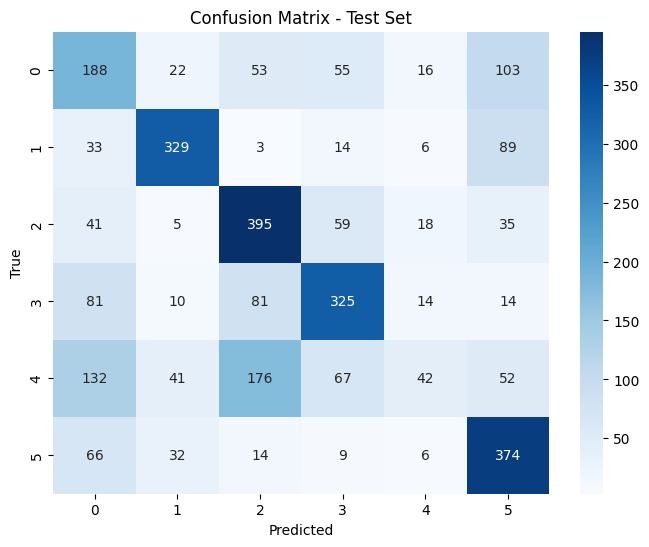

In [ ]:
evaluate_on_test(model_mlp, test_loader, criterion, device)

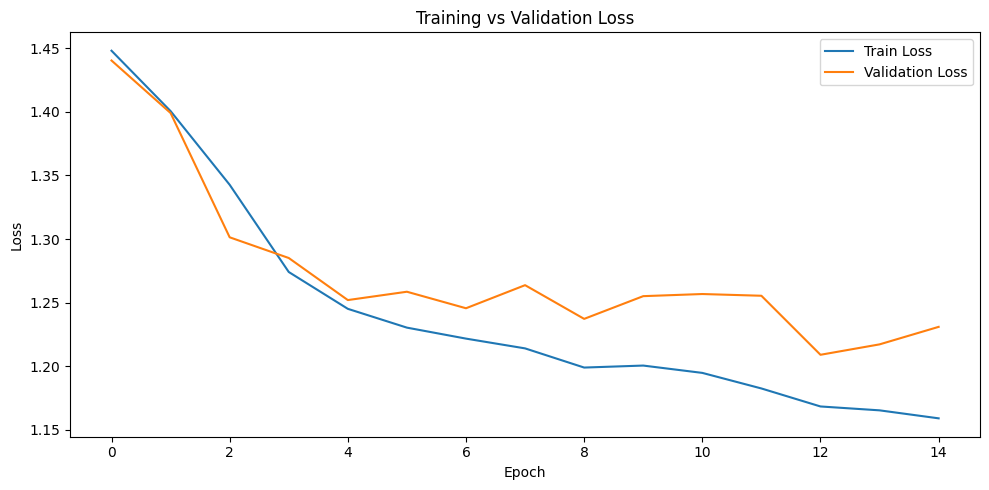

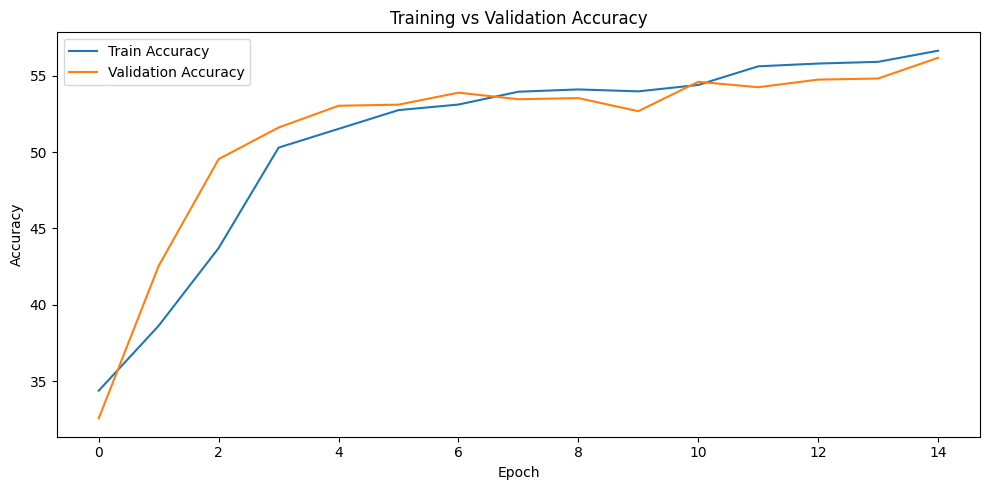

In [ ]:
import matplotlib.pyplot as plt

plot_metrics(history['train_loss'], history['val_loss'], history['train_acc'], history['val_acc'])

Why did MLP perfomed vey bad with an accuracy of 55%?

the answer is

- An MLP performs poorly on the Images because it is "spatially blind". by flattening the 150×150 images into a long 1D string of numbers, the model loses all sense of how pixels relate to their neighbors, that is why 55% accuracy was achieved

##### Lets save the Modelpth file for MLP

In [ ]:
torch.save(model_mlp.state_dict(), 'SimpleMLP-Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


## The Second Model (CNN)!
This is our first spatial model. Unlike the MLP, this CNN uses convolutional layers to extract features from images, followed by a pooling layer to reduce dimensionality, and finally a fully connected layer to map those features to our 6 target classes.
- all CNN will be using CrossEntropy Loss for Softmax behavior as well

In [16]:
class CNN(nn.Module): # switched from MLP to CNN
    def __init__(self, num_classes, mode="plain"):
        super(CNN, self).__init__()

        layers = []

        # Convolutional layers to 'see' patterns in the images
        # first layer, we picked 3 channels since they are rgb images
        layers.append(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1))

        # here we are using mode param to decide which CNN to build for the golden rules
        if mode == "dropout_bn":
            layers.append(nn.BatchNorm2d(16))

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2)) # Reduces image size by half

        layers.append(nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1))

        if mode == "dropout_bn":
            layers.append(nn.BatchNorm2d(32))

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)

        classifier_layers = [ # here we are flattening the output of the conv layers and passing it through one fully connected layers to make the final decision
            nn.Flatten(),
            nn.Linear(32 * 37 * 37, 128), # Update the first number based on your image size!
            nn.ReLU()
        ]

        if mode in ["dropout", "dropout_bn"]:
            classifier_layers.append(nn.Dropout(0.3))

        classifier_layers.append(nn.Linear(128, num_classes))

        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



### Lets run for sanity check and check if the pipeline is healthy to go with for the CNN

In [ ]:
SanityCheck(CNN(6).to(device), 100)

SANITY CHECK: Overfitting on 100 Intel Images
Epoch 10 | Loss: 0.7437 | Acc: 0.7400
Epoch 20 | Loss: 0.3583 | Acc: 0.9000
Epoch 30 | Loss: 0.1422 | Acc: 0.9900
Epoch 40 | Loss: 0.0361 | Acc: 0.9900
Epoch 50 | Loss: 0.0128 | Acc: 1.0000

✅ SUCCESS: Model memorized the subset. The pipeline is healthy!


## Simplest CNN
- here a CNN was built with no dropouts, no batchnorm, and no weight decays. only conv2d and maxpooling2d

In [ ]:
SimpleCnnModel = CNN(6, "plain")
SimpleCnnModel.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(SimpleCnnModel.parameters(), lr=0.0005)

print(SimpleCnnModel)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


Some filters before training:


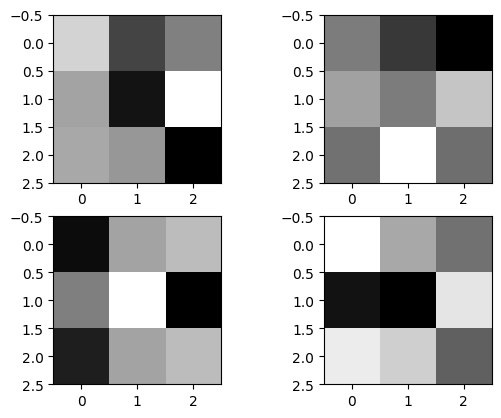

In [ ]:
print("Some filters before training:")

filters_before = SimpleCnnModel.features[0].weight.clone().detach()
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_before[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

In [ ]:
hist = train(SimpleCnnModel, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]: 100%|██████████| 395/395 [00:27<00:00, 14.51it/s, acc=61.7, loss=0.898]


Summary Epoch 1: Train Loss: 1.0074, Train Acc: 61.66% | Val Loss: 1.0012, Val Acc: 62.58%


Epoch [2/15]: 100%|██████████| 395/395 [00:27<00:00, 14.51it/s, acc=71, loss=0.569]


Summary Epoch 2: Train Loss: 0.7666, Train Acc: 70.99% | Val Loss: 0.7600, Val Acc: 72.84%


Epoch [3/15]: 100%|██████████| 395/395 [00:27<00:00, 14.44it/s, acc=75.6, loss=0.717]


...

Summary Epoch 13: Train Loss: 0.3355, Train Acc: 87.86% | Val Loss: 0.5870, Val Acc: 79.47%


Epoch [14/15]: 100%|██████████| 395/395 [00:26<00:00, 14.65it/s, acc=88.3, loss=0.508]


Summary Epoch 14: Train Loss: 0.3264, Train Acc: 88.32% | Val Loss: 0.5950, Val Acc: 79.54%


Epoch [15/15]: 100%|██████████| 395/395 [00:26<00:00, 14.83it/s, acc=88.7, loss=0.31]


Summary Epoch 15: Train Loss: 0.3075, Train Acc: 88.74% | Val Loss: 0.6091, Val Acc: 80.83%


In [ ]:
val_loss, val_acc, _, _ = evaluate_model(SimpleCnnModel, val_loader, criterion, device)
print("Val_Loss = ", val_loss)
print("Val_Acc = ", val_acc)

Val_Loss =  0.5988076395930686
Val_Acc =  0.8061297220242338


TEST SET EVALUATION
Test Loss: 0.5423
Test Accuracy: 0.8223
----------------------------------------
Macro Precision: 0.8276
Macro Recall: 0.8269
Macro F1-score: 0.8236
----------------------------------------
Weighted Precision: 0.8283
Weighted Recall: 0.8223
Weighted F1-score: 0.8217

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.87      0.79       437
           1       0.96      0.96      0.96       474
           2       0.84      0.69      0.76       553
           3       0.77      0.79      0.78       525
           4       0.78      0.88      0.83       510
           5       0.89      0.77      0.82       501

    accuracy                           0.82      3000
   macro avg       0.83      0.83      0.82      3000
weighted avg       0.83      0.82      0.82      3000



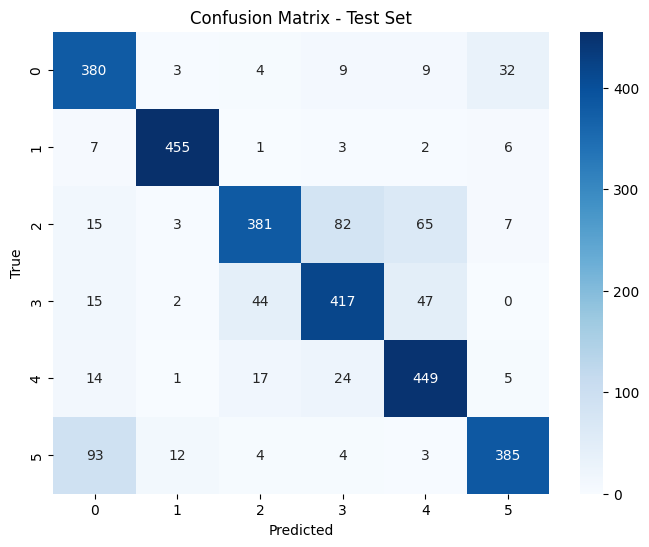

In [ ]:
evaluate_on_test(SimpleCnnModel, test_loader, criterion, device)

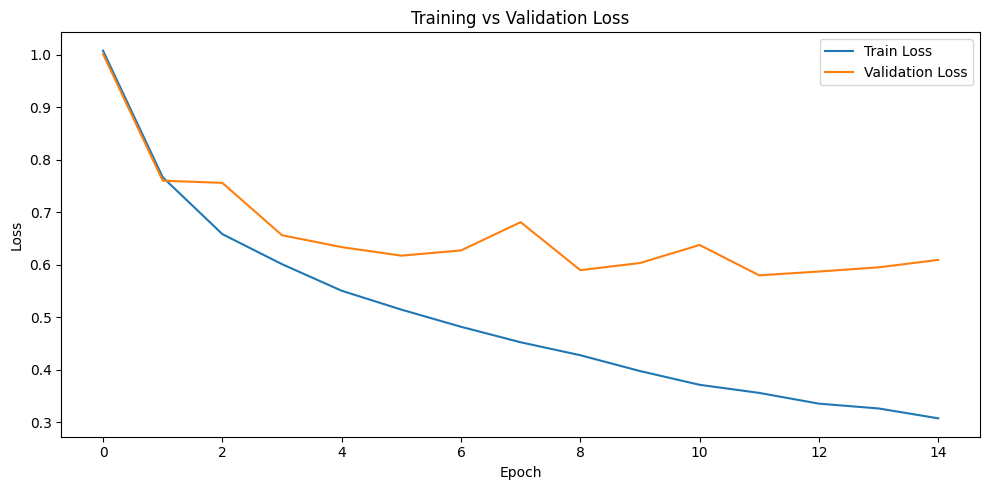

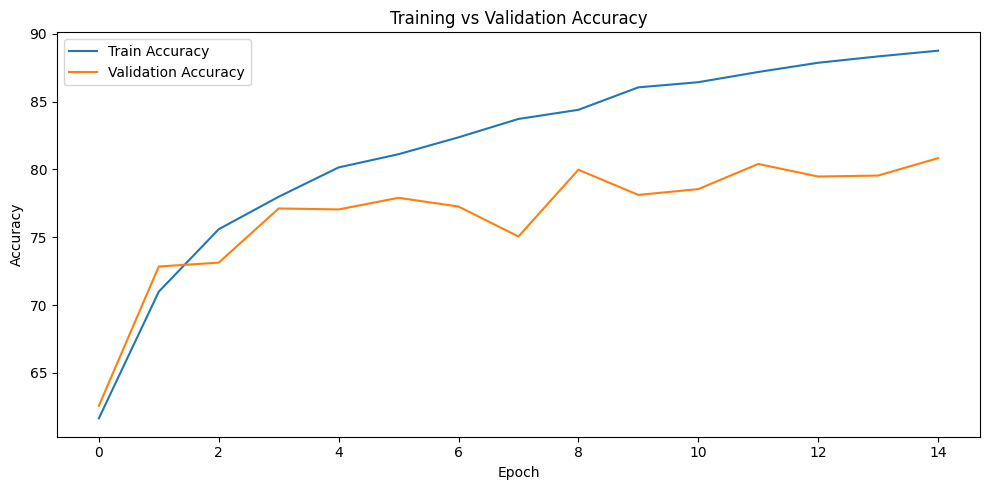

In [ ]:
plot_metrics(hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'])

### Performance is much better than the MLP but it is a bit overfitting the data

In [ ]:
torch.save(SimpleCnnModel.state_dict(), 'CNNSimple_Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


In [ ]:
# after training
filters_after = SimpleCnnModel.features[0].weight.clone().detach()

Some filters after training:


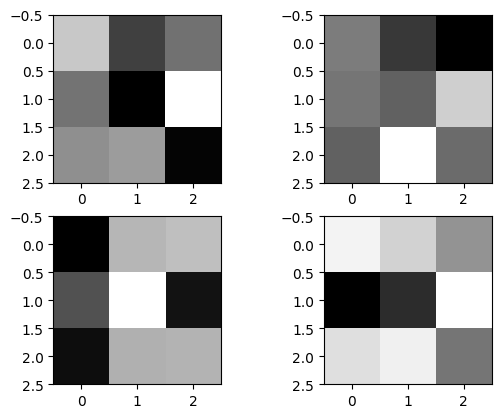

In [ ]:
print("Some filters after training:")
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_after[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

### **SimpleCNN Feature Maps Plotting**

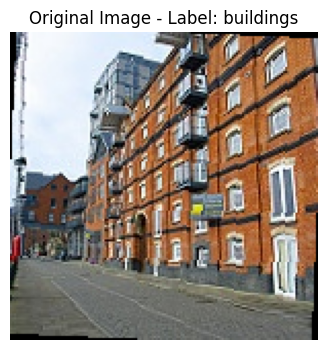

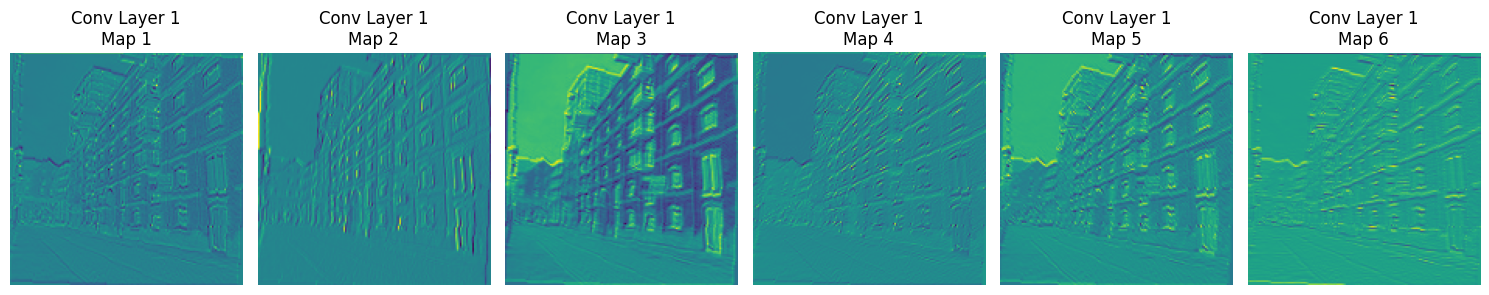

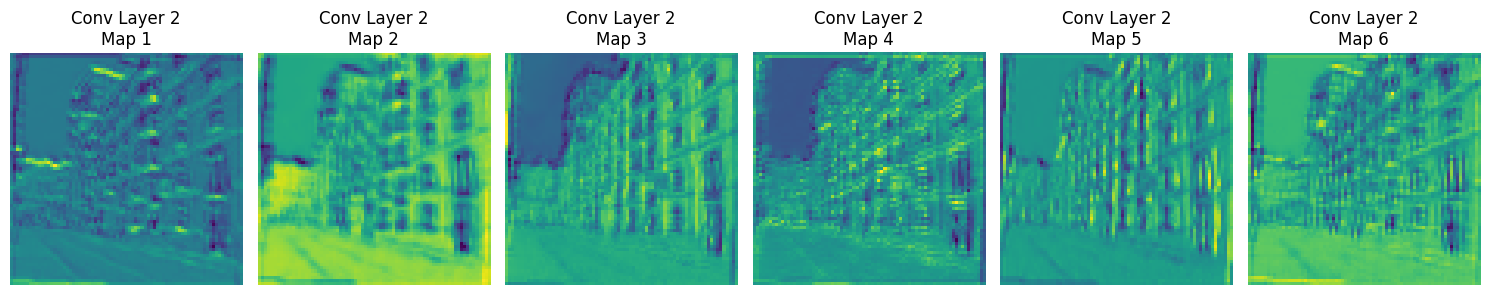

In [ ]:
plot_feature_maps(SimpleCnnModel, test_dataset, device, architecture="custom", class_names=test_dataset.classes)

# CNN With Dropout

In [17]:
DropoutCnnModel = CNN(6, "dropout")
DropoutCnnModel.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(DropoutCnnModel.parameters(), lr=0.0005)

print(DropoutCnnModel)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


Some filters before training:


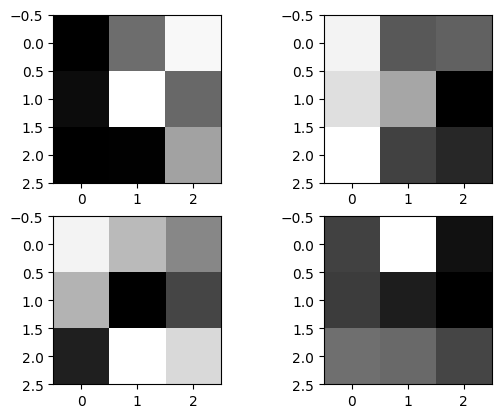

In [ ]:
print("Some filters before training:")
filters_before = DropoutCnnModel.features[0].weight.clone().detach()
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_before[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

In [18]:
hist = train(DropoutCnnModel, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]: 100%|██████████| 395/395 [01:14<00:00,  5.28it/s, acc=56, loss=0.839]


Summary Epoch 1: Train Loss: 1.1244, Train Acc: 55.96% | Val Loss: 0.9456, Val Acc: 63.15%


Epoch [2/15]: 100%|██████████| 395/395 [00:26<00:00, 14.77it/s, acc=67.5, loss=0.77]


Summary Epoch 2: Train Loss: 0.8591, Train Acc: 67.52% | Val Loss: 0.8223, Val Acc: 70.78%


Epoch [3/15]: 100%|██████████| 395/395 [00:26<00:00, 14.81it/s, acc=71.6, loss=0.555]


...

Summary Epoch 13: Train Loss: 0.4526, Train Acc: 83.69% | Val Loss: 0.5777, Val Acc: 80.47%


Epoch [14/15]: 100%|██████████| 395/395 [00:26<00:00, 14.78it/s, acc=84.2, loss=0.463]


Summary Epoch 14: Train Loss: 0.4394, Train Acc: 84.22% | Val Loss: 0.5714, Val Acc: 79.47%


Epoch [15/15]: 100%|██████████| 395/395 [00:29<00:00, 13.54it/s, acc=84.9, loss=0.573]


Summary Epoch 15: Train Loss: 0.4217, Train Acc: 84.94% | Val Loss: 0.5762, Val Acc: 79.90%


In [20]:
val_loss, val_acc, _, _ = evaluate_model(DropoutCnnModel, val_loader, criterion, device)
print("Val_Loss = ", val_loss)
print("Val_Acc = ", val_acc)

Val_Loss =  0.5713898559935332
Val_Acc =  0.8075552387740556


TEST SET EVALUATION
Test Loss: 0.5120
Test Accuracy: 0.8283
----------------------------------------
Macro Precision: 0.8318
Macro Recall: 0.8313
Macro F1-score: 0.8299
----------------------------------------
Weighted Precision: 0.8313
Weighted Recall: 0.8283
Weighted F1-score: 0.8280

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       437
           1       0.91      0.97      0.94       474
           2       0.85      0.73      0.79       553
           3       0.72      0.82      0.77       525
           4       0.83      0.82      0.83       510
           5       0.87      0.82      0.85       501

    accuracy                           0.83      3000
   macro avg       0.83      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



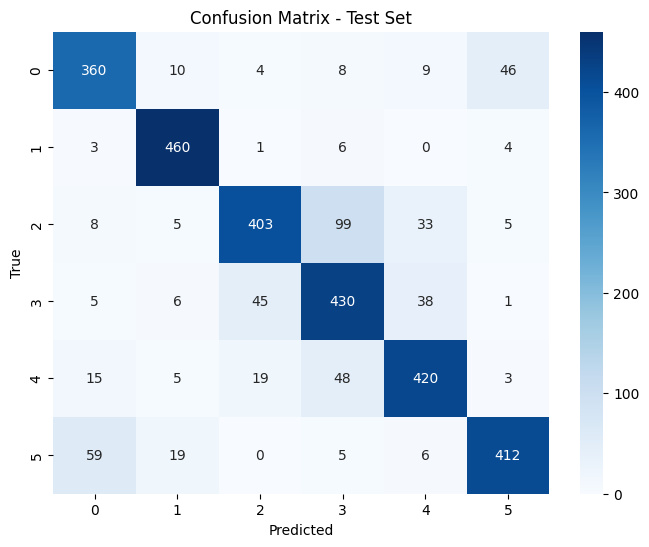

In [21]:
evaluate_on_test(DropoutCnnModel, test_loader, criterion, device)

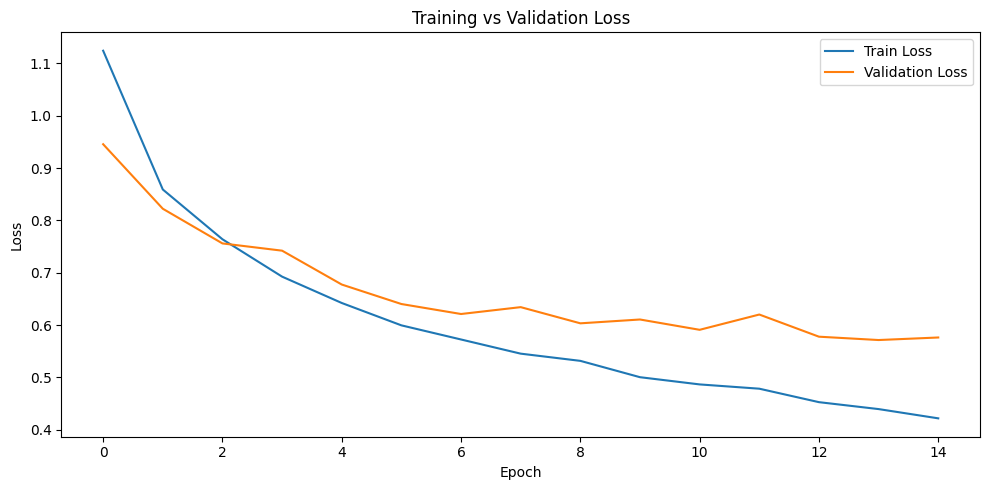

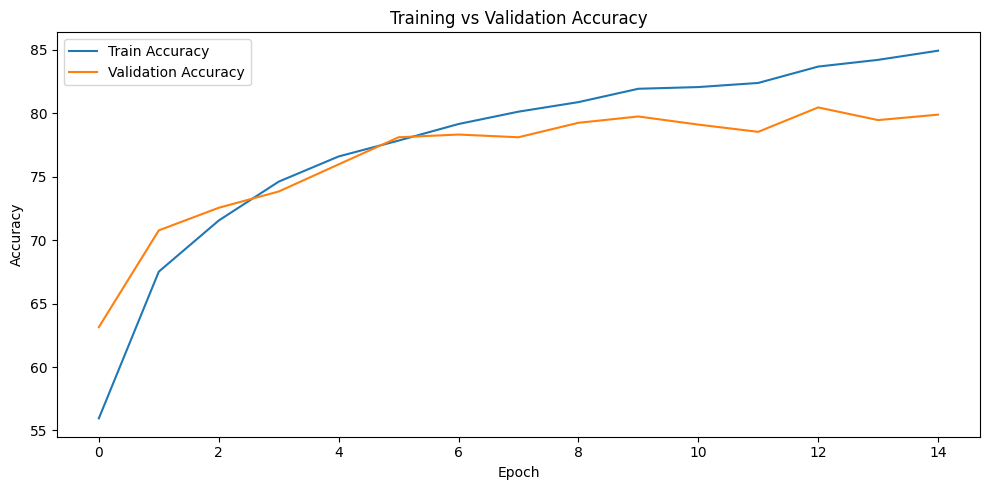

In [22]:
plot_metrics(hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'])

- In this model, the generalization gap has been reduced which means the drop out really had an effect. Lets try a last one with dropout, batchnorm and weight decay

In [23]:
torch.save(DropoutCnnModel.state_dict(), 'CNNComplex_Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


In [24]:
# after training
filters_after = DropoutCnnModel.features[0].weight.clone().detach()

Some filters after training:


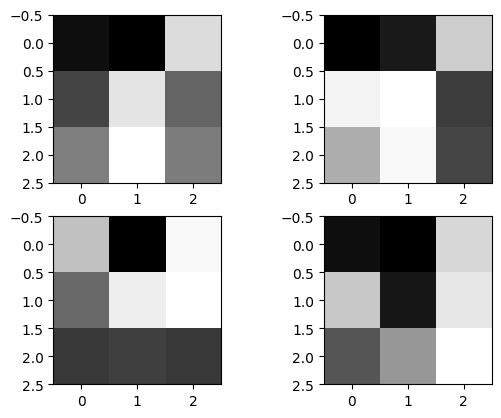

In [25]:
print("Some filters after training:")
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_after[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

### Feature Maps for the 2nd CNN Model (With Drop-Out)

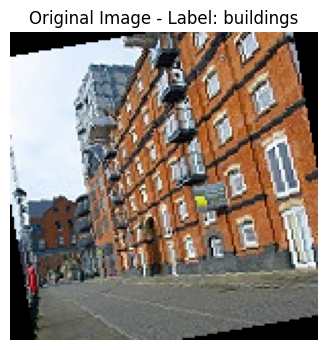

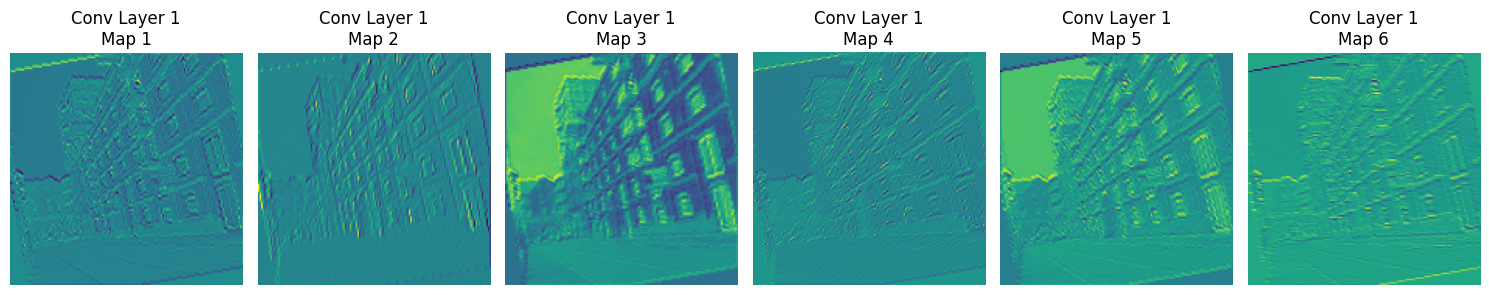

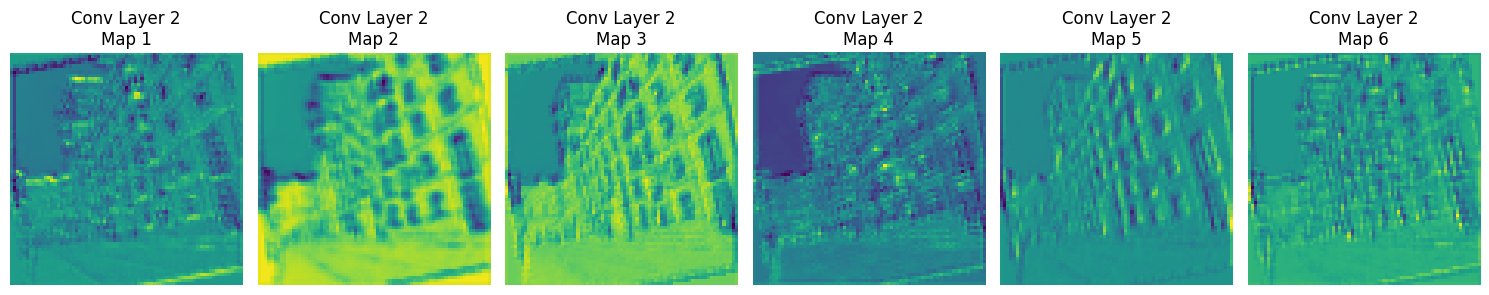

In [50]:
plot_feature_maps(DropoutCnnModel, test_dataset, device, architecture="custom", class_names=test_dataset.classes)

# CNN With Dropout, Weight Decay, BatchNorm and Lr Schedule

In [ ]:
BatchNormDropoutCnnModel = CNN(6, "dropout_bn")
BatchNormDropoutCnnModel.to(device)

criterion = nn.CrossEntropyLoss()

# weight decay helps regularization
optimizer = torch.optim.Adam(
    BatchNormDropoutCnnModel.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print(BatchNormDropoutCnnModel)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


Some filters before training:


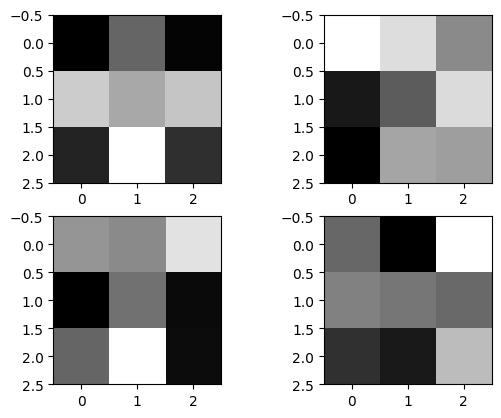

In [ ]:
print("Some filters before training:")

filters_before = BatchNormDropoutCnnModel.features[0].weight.clone().detach()
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_before[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

In [ ]:
hist = train(BatchNormDropoutCnnModel, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]: 100%|██████████| 395/395 [00:28<00:00, 13.81it/s, acc=50.8, loss=1.29]


Summary Epoch 1: Train Loss: 1.3695, Train Acc: 50.80% | Val Loss: 0.9993, Val Acc: 61.08%


Epoch [2/15]: 100%|██████████| 395/395 [00:28<00:00, 13.99it/s, acc=59.5, loss=0.888]


Summary Epoch 2: Train Loss: 1.0253, Train Acc: 59.51% | Val Loss: 0.8732, Val Acc: 66.64%


Epoch [3/15]: 100%|██████████| 395/395 [00:28<00:00, 14.04it/s, acc=64.9, loss=0.843]


...

Summary Epoch 13: Train Loss: 0.6881, Train Acc: 74.20% | Val Loss: 0.6163, Val Acc: 78.33%


Epoch [14/15]: 100%|██████████| 395/395 [00:28<00:00, 13.75it/s, acc=74.3, loss=0.272]


Summary Epoch 14: Train Loss: 0.6772, Train Acc: 74.29% | Val Loss: 0.6411, Val Acc: 77.26%


Epoch [15/15]: 100%|██████████| 395/395 [00:28<00:00, 13.84it/s, acc=74.8, loss=0.863]


Summary Epoch 15: Train Loss: 0.6699, Train Acc: 74.82% | Val Loss: 0.6797, Val Acc: 77.55%


In [ ]:
val_loss, val_acc, _, _ = evaluate_model(BatchNormDropoutCnnModel, val_loader, criterion, device)
print("Val_Loss = ", val_loss)
print("Val_Acc = ", val_acc)

Val_Loss =  0.6874348839435591
Val_Acc =  0.7719173200285103


TEST SET EVALUATION
Test Loss: 0.6542
Test Accuracy: 0.7537
----------------------------------------
Macro Precision: 0.7836
Macro Recall: 0.7547
Macro F1-score: 0.7492
----------------------------------------
Weighted Precision: 0.7796
Weighted Recall: 0.7537
Weighted F1-score: 0.7462

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.72      0.75       437
           1       0.95      0.92      0.93       474
           2       0.71      0.75      0.73       553
           3       0.60      0.84      0.70       525
           4       0.89      0.40      0.56       510
           5       0.77      0.89      0.82       501

    accuracy                           0.75      3000
   macro avg       0.78      0.75      0.75      3000
weighted avg       0.78      0.75      0.75      3000



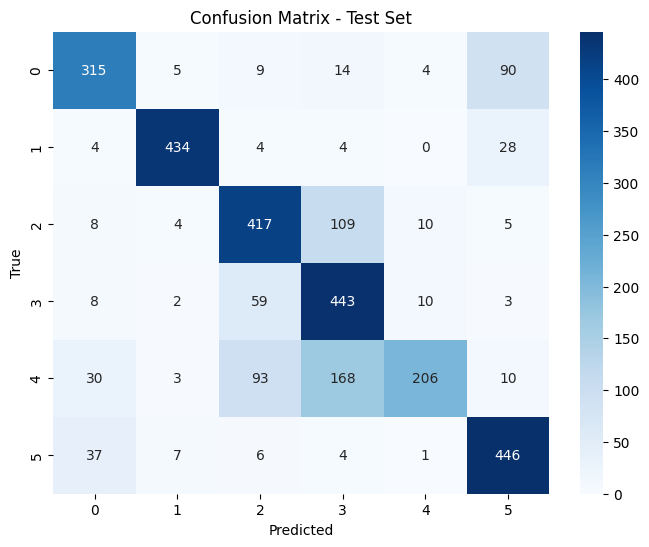

In [ ]:
evaluate_on_test(BatchNormDropoutCnnModel, test_loader, criterion, device)

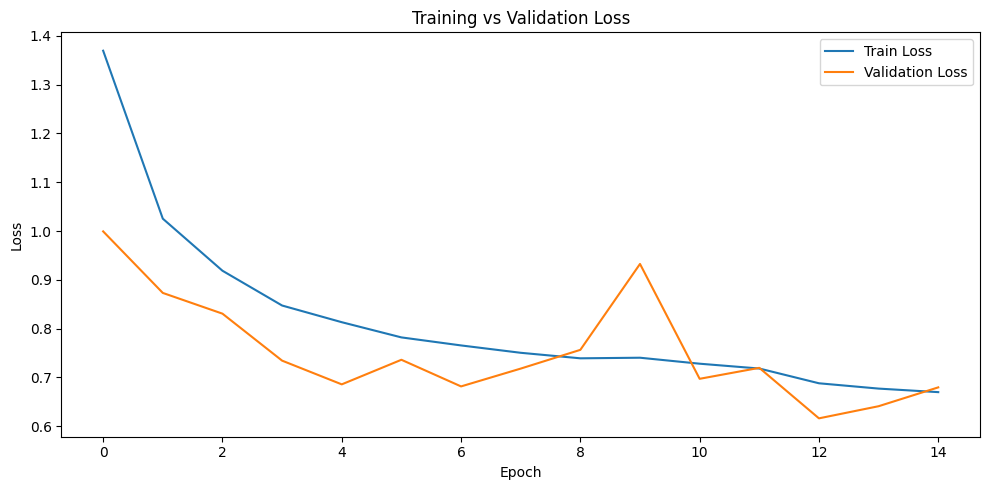

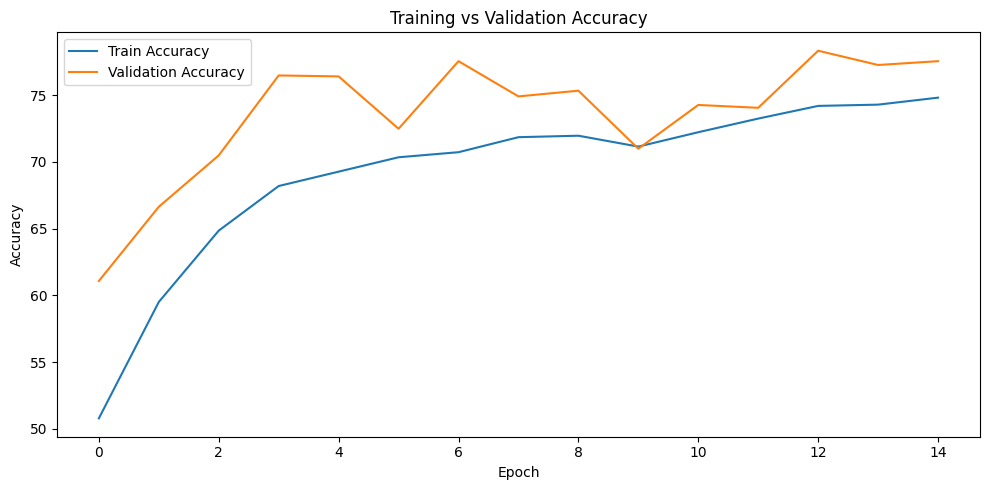

In [ ]:
plot_metrics(hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'])

### Unforftnately, addign batchnorm and weight decay caused the model to have a less accuracies in both val and train. Additionally the macro metrics is worse than the CNN with drop out model. best model at this point is the 2nd (CNN with dropouts only)

In [ ]:
torch.save(BatchNormDropoutCnnModel.state_dict(), 'CNNRegularized_Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


In [ ]:
# after training
filters_after = BatchNormDropoutCnnModel.features[0].weight.clone().detach()

Some filters after training:


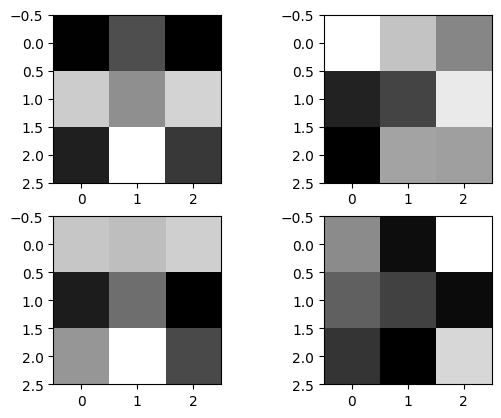

In [ ]:
print("Some filters after training:")

fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_after[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

##### Here we are plotting some of the filters after training

### **BN-CNN Feature Maps Plotting**

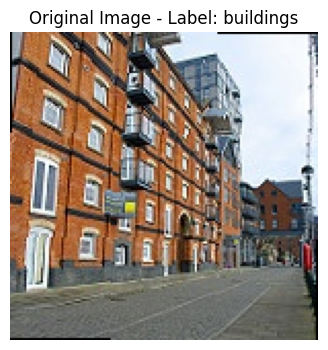

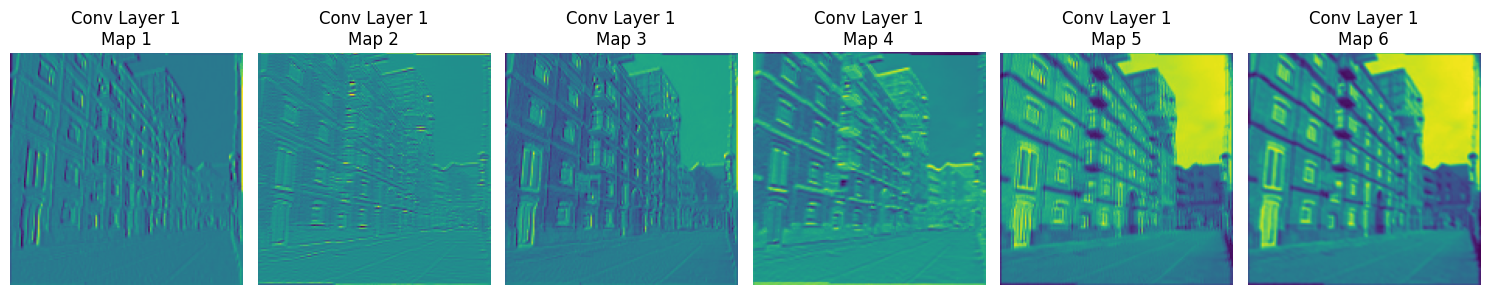

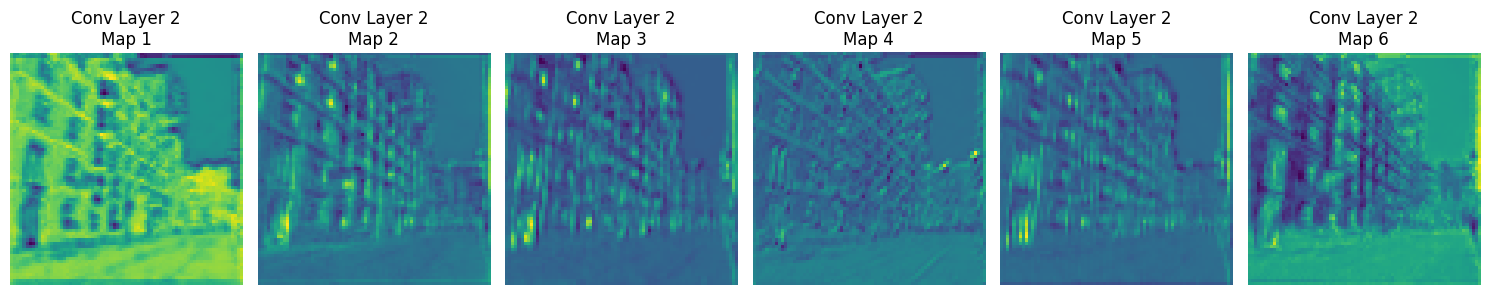

In [ ]:
plot_feature_maps(BatchNormDropoutCnnModel, test_dataset, device, architecture="custom", class_names=test_dataset.classes)

The last model, which is the most complex one and it is a pretrained model. I will load the ResNet18 architecture, which has been pretrained on millions of images from the ImageNet database.

By using Transfer Learning, we can take the "knowledge" this model already has like recognizing textures and complex shapes and fine-tune or freeze the last layers and retrain them.

In [32]:
import torchvision.models as models

def build_resnet(mode="fc_only", num_classes=6, device="cuda", lr = 0.001):

    # load pretrained resnet18 trained on imagenet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # replace the last fully connected layer
    # original resnet outputs 1000 classes but our dataset has 6
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(256, num_classes)
    )

    # transfer learning scenarios
    # similar to the CNn, we will use the mode param to decide which layers to freeze
    # and which to train based on the golden rules of transfer learning
    if mode == "fc_only": # scenarion a

        # freeze the whole network first
        for param in model.parameters():
            param.requires_grad = False

        # train only the classifier layer
        for param in model.fc.parameters():
            param.requires_grad = True


    elif mode == "finetune_last": # scenario b

        # freeze everything first
        for param in model.parameters():
            param.requires_grad = False # here we do the freezing


        # these layers learn higher level features
        for param in model.layer4.parameters():
            param.requires_grad = True # here we unfreeze the last convolution block

        # also train the classifier
        for param in model.fc.parameters():
            param.requires_grad = True


    elif mode == "finetune_all": #scenario c

        # train the entire network
        for param in model.parameters():    # this allows the model to fully adapt to the dataset
            param.requires_grad = True


    model = model.to(device)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr # learning rat of 0.001
    )

    criterion = nn.CrossEntropyLoss()

    return model, optimizer, criterion

In [33]:
import matplotlib.pyplot as plt

def plot_transfer_metrics(hist_fc, hist_last, hist_all):

    histories = [
        ("FC Only", hist_fc),
        ("Finetune Last", hist_last),
        ("Finetune All", hist_all)
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 12))

    for i, (title, hist) in enumerate(histories):

        # loss plot
        axes[i,0].plot(hist["train_loss"], label="train")
        axes[i,0].plot(hist["val_loss"], label="val")
        axes[i,0].set_title(f"{title} Loss")
        axes[i,0].set_xlabel("epoch")
        axes[i,0].set_ylabel("loss")
        axes[i,0].legend()

        # accuracy plot
        axes[i,1].plot(hist["train_acc"], label="train")
        axes[i,1].plot(hist["val_acc"], label="val")
        axes[i,1].set_title(f"{title} Accuracy")
        axes[i,1].set_xlabel("epoch")
        axes[i,1].set_ylabel("accuracy")
        axes[i,1].legend()

    plt.tight_layout()
    plt.show()

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Initializing the Resnet Models

In [35]:
model_fc_only, optimizerA, criterionA = build_resnet("fc_only", 6, device, 0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


In [36]:
model_finetune_last, optimizerB, criterionB = build_resnet("finetune_last", 6, device, 0.001)

In [37]:
model_finetune_all, optimizerC, criterionC = build_resnet("finetune_all", 6, device, 0.0008)

### Training the 3 ResNet inintialized models

In [38]:
histA = train(model_fc_only, optimizerA, criterionA, 10, device, train_loader, val_loader)

Epoch [1/10]: 100%|██████████| 395/395 [00:29<00:00, 13.20it/s, acc=80.1, loss=0.333]


Summary Epoch 1: Train Loss: 0.5571, Train Acc: 80.08% | Val Loss: 0.4147, Val Acc: 85.17%


Epoch [2/10]: 100%|██████████| 395/395 [00:28<00:00, 13.80it/s, acc=84.3, loss=0.479]


Summary Epoch 2: Train Loss: 0.4311, Train Acc: 84.29% | Val Loss: 0.3931, Val Acc: 86.03%


Epoch [3/10]: 100%|██████████| 395/395 [00:28<00:00, 13.78it/s, acc=85.6, loss=0.141]


...

Summary Epoch 8: Train Loss: 0.3580, Train Acc: 87.00% | Val Loss: 0.3307, Val Acc: 88.17%


Epoch [9/10]: 100%|██████████| 395/395 [00:29<00:00, 13.56it/s, acc=86.9, loss=0.319]


Summary Epoch 9: Train Loss: 0.3480, Train Acc: 86.87% | Val Loss: 0.3340, Val Acc: 87.38%


Epoch [10/10]: 100%|██████████| 395/395 [00:41<00:00,  9.60it/s, acc=87.2, loss=0.104]


Summary Epoch 10: Train Loss: 0.3486, Train Acc: 87.23% | Val Loss: 0.4030, Val Acc: 85.32%


In [39]:
histB = train(model_finetune_last, optimizerB, criterionB, 10, device, train_loader, val_loader)

Epoch [1/10]: 100%|██████████| 395/395 [00:31<00:00, 12.41it/s, acc=86.8, loss=0.587]


Summary Epoch 1: Train Loss: 0.3910, Train Acc: 86.82% | Val Loss: 0.2972, Val Acc: 90.81%


Epoch [2/10]: 100%|██████████| 395/395 [00:30<00:00, 13.03it/s, acc=90.5, loss=0.0879]


Summary Epoch 2: Train Loss: 0.2789, Train Acc: 90.46% | Val Loss: 0.2678, Val Acc: 91.30%


Epoch [3/10]: 100%|██████████| 395/395 [00:31<00:00, 12.59it/s, acc=91.5, loss=0.561]


...

Summary Epoch 8: Train Loss: 0.1379, Train Acc: 95.19% | Val Loss: 0.2775, Val Acc: 92.59%


Epoch [9/10]: 100%|██████████| 395/395 [00:30<00:00, 12.95it/s, acc=95.6, loss=0.186]


Summary Epoch 9: Train Loss: 0.1250, Train Acc: 95.64% | Val Loss: 0.2826, Val Acc: 93.01%


Epoch [10/10]: 100%|██████████| 395/395 [00:30<00:00, 13.08it/s, acc=96, loss=0.106]


Summary Epoch 10: Train Loss: 0.1086, Train Acc: 96.03% | Val Loss: 0.3005, Val Acc: 92.73%


In [40]:
histC = train(model_finetune_all, optimizerC, criterionC, 10, device, train_loader, val_loader)

Epoch [1/10]: 100%|██████████| 395/395 [00:39<00:00,  9.99it/s, acc=82.5, loss=0.297]


Summary Epoch 1: Train Loss: 0.5266, Train Acc: 82.53% | Val Loss: 0.5723, Val Acc: 81.25%


Epoch [2/10]: 100%|██████████| 395/395 [00:39<00:00, 10.07it/s, acc=86.8, loss=0.339]


Summary Epoch 2: Train Loss: 0.3853, Train Acc: 86.83% | Val Loss: 0.3251, Val Acc: 88.24%


Epoch [3/10]: 100%|██████████| 395/395 [00:39<00:00,  9.94it/s, acc=88.5, loss=0.262]


...

Summary Epoch 8: Train Loss: 0.2402, Train Acc: 91.63% | Val Loss: 0.3777, Val Acc: 87.38%


Epoch [9/10]: 100%|██████████| 395/395 [00:40<00:00,  9.85it/s, acc=92.3, loss=0.253]


Summary Epoch 9: Train Loss: 0.2283, Train Acc: 92.28% | Val Loss: 0.3201, Val Acc: 87.95%


Epoch [10/10]: 100%|██████████| 395/395 [00:40<00:00,  9.80it/s, acc=92.7, loss=0.154]


Summary Epoch 10: Train Loss: 0.2202, Train Acc: 92.66% | Val Loss: 0.3112, Val Acc: 89.67%


In [41]:
# i am re-evaluating to get the "Clean" metrics and logging them in a nice format in the end.
scenarios = {
    "FC Only": (model_fc_only, criterionA),
    "Finetune Last Layers": (model_finetune_last, criterionB),
    "Finetune All": (model_finetune_all, criterionC)
}

for name, (model, criterion) in scenarios.items():

    train_loss_final, train_acc_final, _, _ = evaluate_model(model, train_loader, criterion, device)
    val_loss_final, val_acc_final, _, _ = evaluate_model(model, val_loader, criterion, device)

    print("\n")
    print("="*50)
    print(f"{name}")
    print("="*50)
    print(f"{'METRIC':<20} | {'VALUE':<10}")
    print("="*50)
    print(f"{'Final Train Loss':<20} | {train_loss_final:.4f}")
    print(f"{'Final Train Acc':<20} | {train_acc_final*100:.2f}%")
    print("-" * 50)
    print(f"{'Final Val Loss':<20} | {val_loss_final:.4f}")
    print(f"{'Final Val Acc':<20} | {val_acc_final*100:.2f}%")
    print("-" * 50)
    print(f"{'Generalization Gap':<20} | {np.abs((val_acc_final - train_acc_final))*100:.2f}%")
    print("="*50)



FC Only
METRIC               | VALUE     
Final Train Loss     | 0.2991
Final Train Acc      | 88.35%
--------------------------------------------------
Final Val Loss       | 0.3710
Final Val Acc        | 86.74%
--------------------------------------------------
Generalization Gap   | 1.60%


Finetune Last Layers
METRIC               | VALUE     
Final Train Loss     | 0.0476
Final Train Acc      | 98.36%
--------------------------------------------------
Final Val Loss       | 0.2971
Final Val Acc        | 92.94%
--------------------------------------------------
Generalization Gap   | 5.42%


Finetune All
METRIC               | VALUE     
Final Train Loss     | 0.1932
Final Train Acc      | 93.51%
--------------------------------------------------
Final Val Loss       | 0.3112
Final Val Acc        | 89.59%
--------------------------------------------------
Generalization Gap   | 3.91%


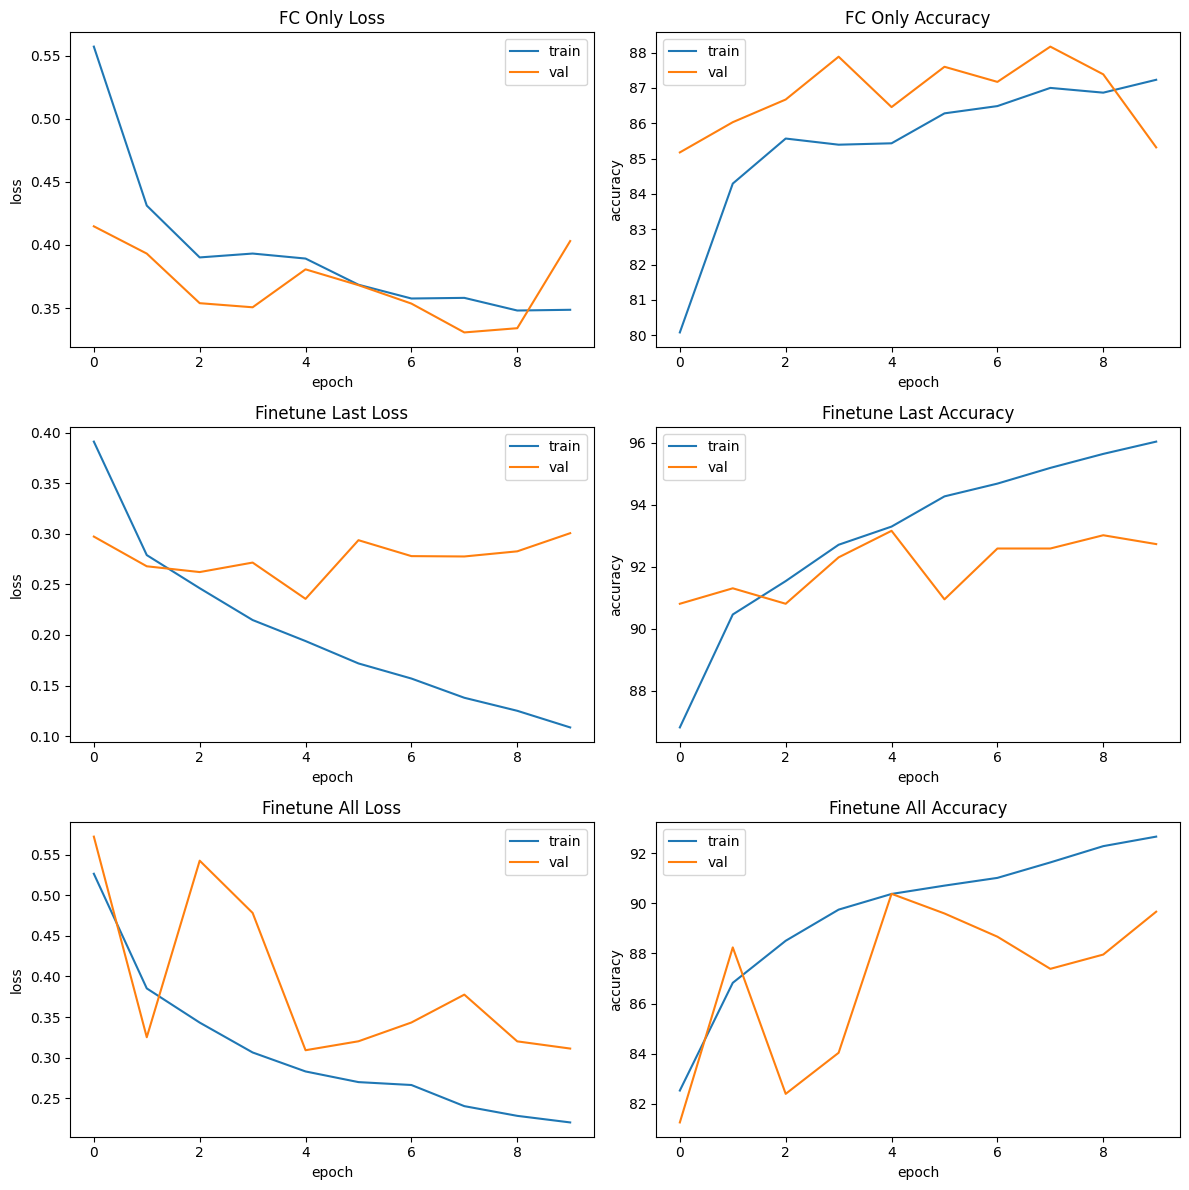

In [42]:
plot_transfer_metrics(histA, histB, histC)

TEST SET EVALUATION
Test Loss: 0.3550
Test Accuracy: 0.8690
----------------------------------------
Macro Precision: 0.8795
Macro Recall: 0.8688
Macro F1-score: 0.8696
----------------------------------------
Weighted Precision: 0.8755
Weighted Recall: 0.8690
Weighted F1-score: 0.8677

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.77      0.85       437
           1       0.99      0.97      0.98       474
           2       0.78      0.87      0.82       553
           3       0.90      0.72      0.80       525
           4       0.82      0.96      0.89       510
           5       0.85      0.92      0.88       501

    accuracy                           0.87      3000
   macro avg       0.88      0.87      0.87      3000
weighted avg       0.88      0.87      0.87      3000



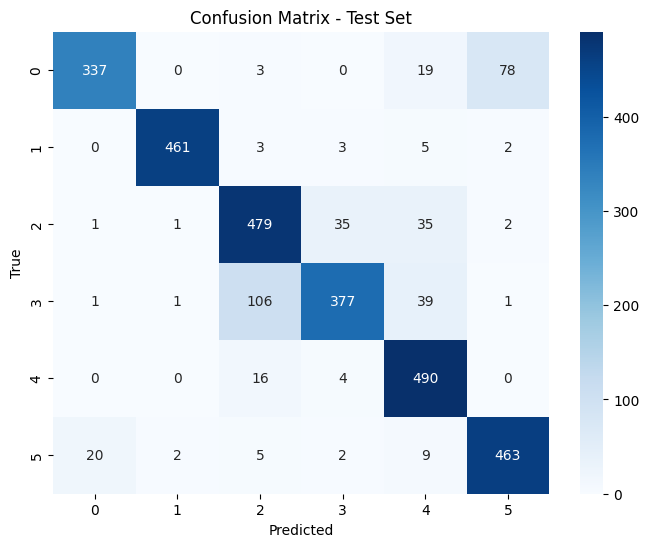

In [43]:
evaluate_on_test(model_fc_only, test_loader, criterionA, device)

TEST SET EVALUATION
Test Loss: 0.2752
Test Accuracy: 0.9240
----------------------------------------
Macro Precision: 0.9256
Macro Recall: 0.9257
Macro F1-score: 0.9255
----------------------------------------
Weighted Precision: 0.9238
Weighted Recall: 0.9240
Weighted F1-score: 0.9237

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       437
           1       0.98      0.99      0.98       474
           2       0.88      0.87      0.88       553
           3       0.90      0.86      0.88       525
           4       0.92      0.97      0.94       510
           5       0.94      0.94      0.94       501

    accuracy                           0.92      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.92      0.92      0.92      3000



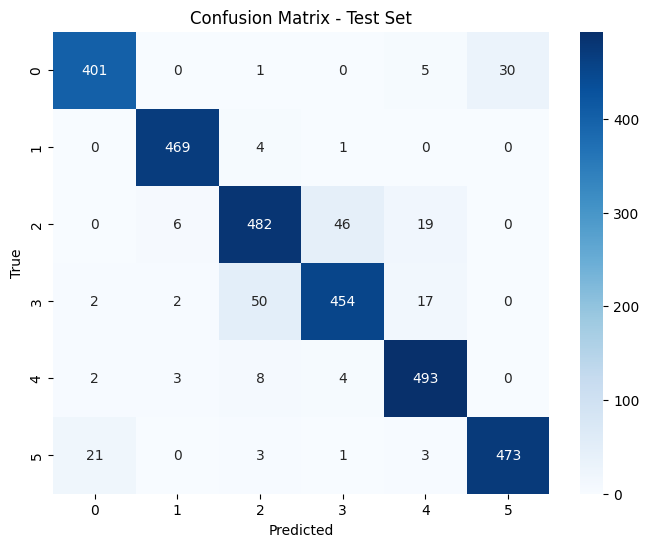

In [44]:
evaluate_on_test(model_finetune_last, test_loader, criterionB, device)

TEST SET EVALUATION
Test Loss: 0.2943
Test Accuracy: 0.8967
----------------------------------------
Macro Precision: 0.8988
Macro Recall: 0.8985
Macro F1-score: 0.8972
----------------------------------------
Weighted Precision: 0.8979
Weighted Recall: 0.8967
Weighted F1-score: 0.8958

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.86      0.88       437
           1       0.95      0.98      0.97       474
           2       0.92      0.78      0.84       553
           3       0.85      0.89      0.87       525
           4       0.86      0.94      0.90       510
           5       0.91      0.93      0.92       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



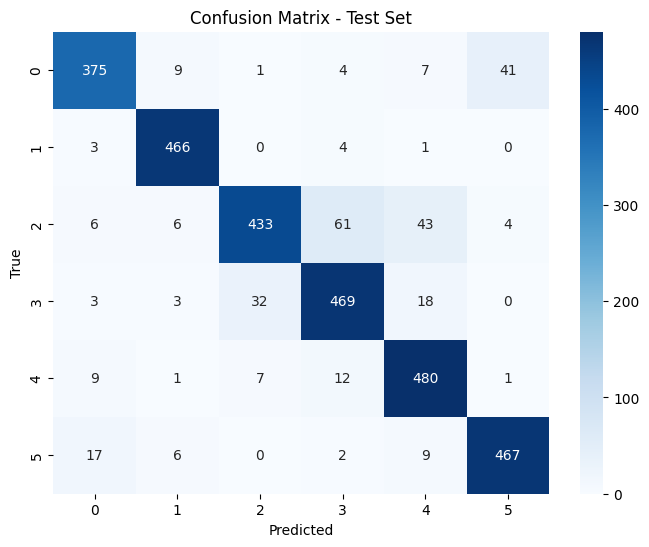

In [45]:
evaluate_on_test(model_finetune_all, test_loader, criterionC, device)

## **Feature Maps for the the 3 versions of the Pretrained ResNet18 Model**

##### **FC Only**

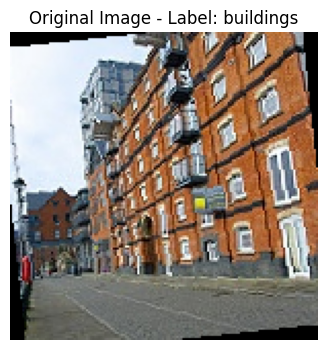

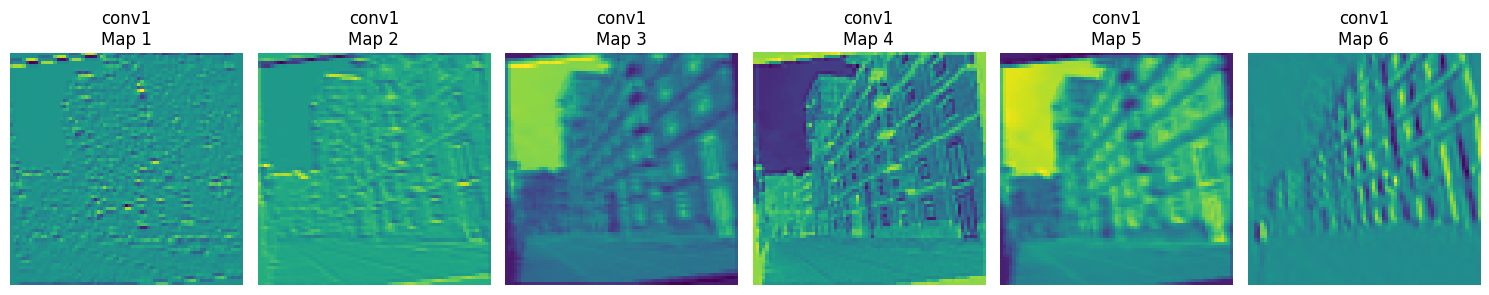

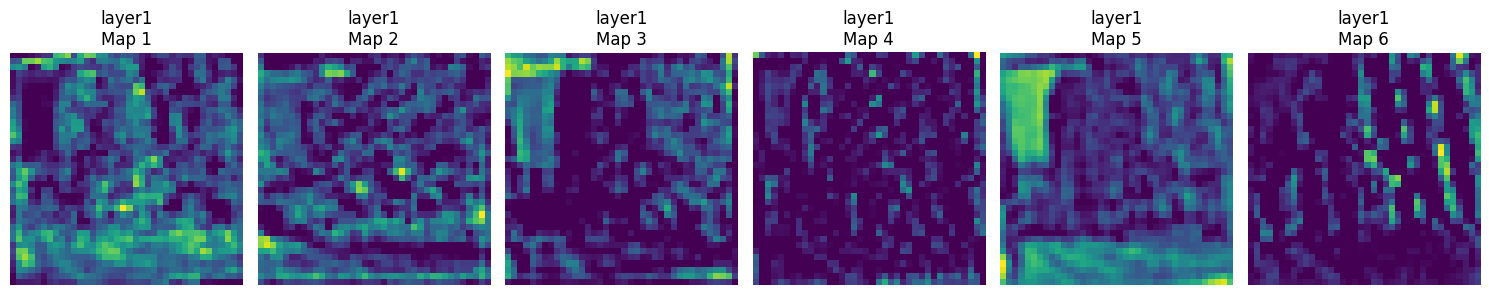

In [51]:
plot_feature_maps(model_fc_only, test_dataset, device, architecture="resnet", class_names=test_dataset.classes)

##### **Finetune Last Layers**

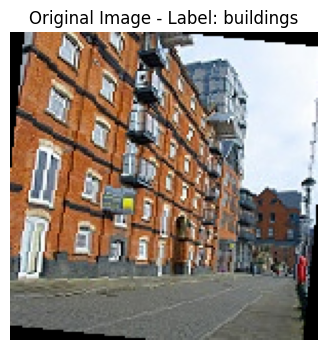

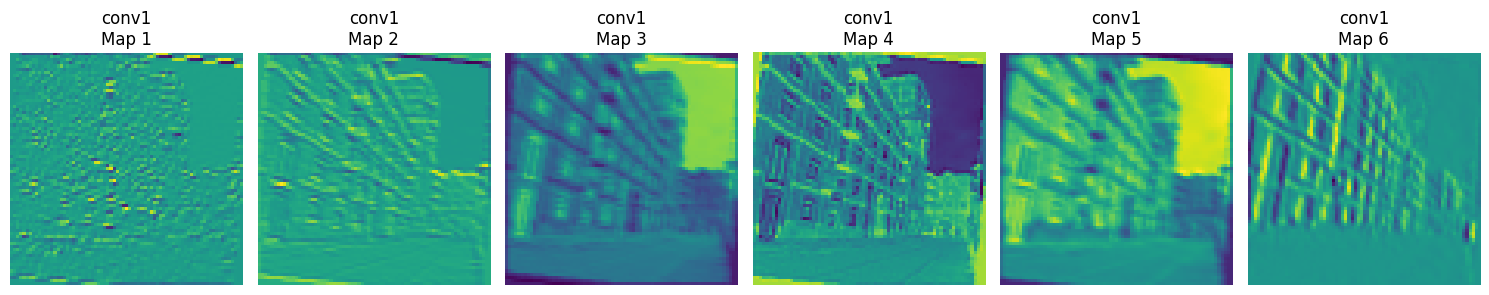

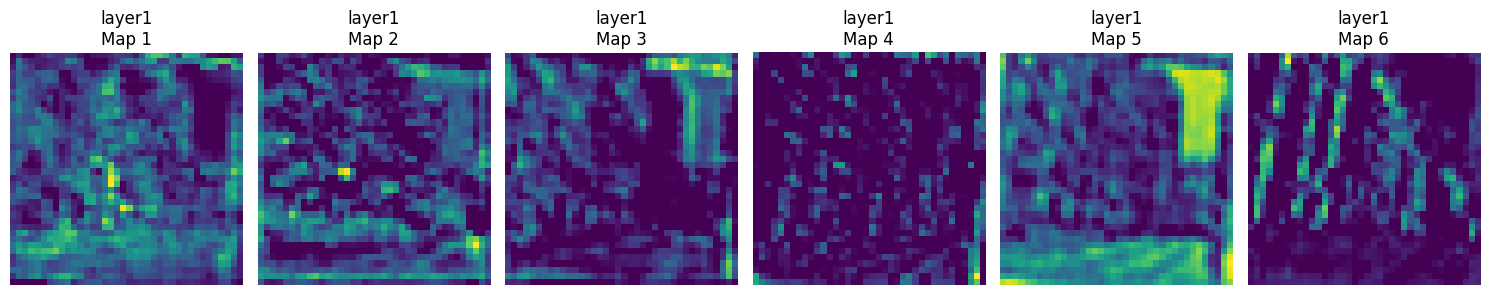

In [52]:
plot_feature_maps(model_finetune_last, test_dataset, device, architecture="resnet", class_names=test_dataset.classes)

##### **Finetune All**

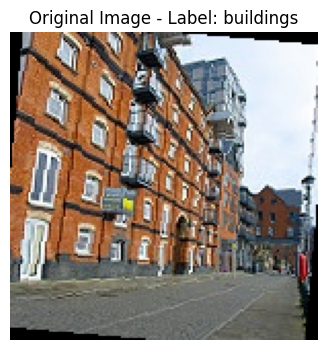

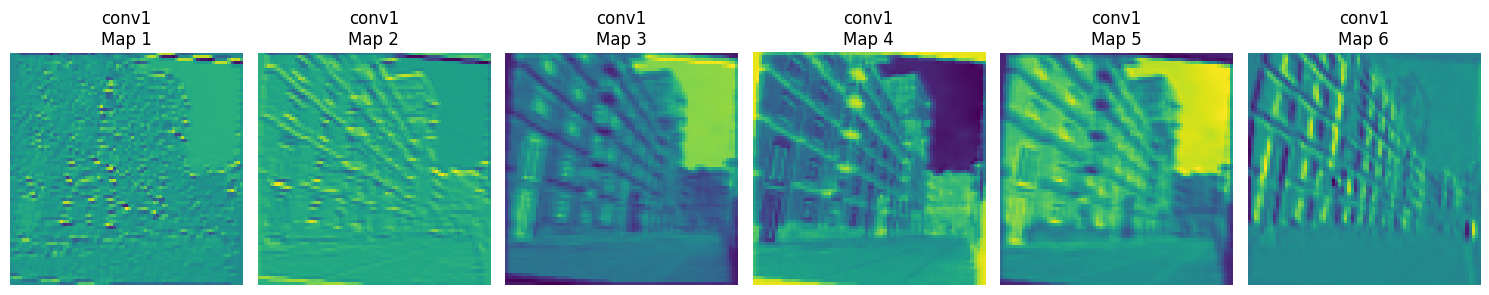

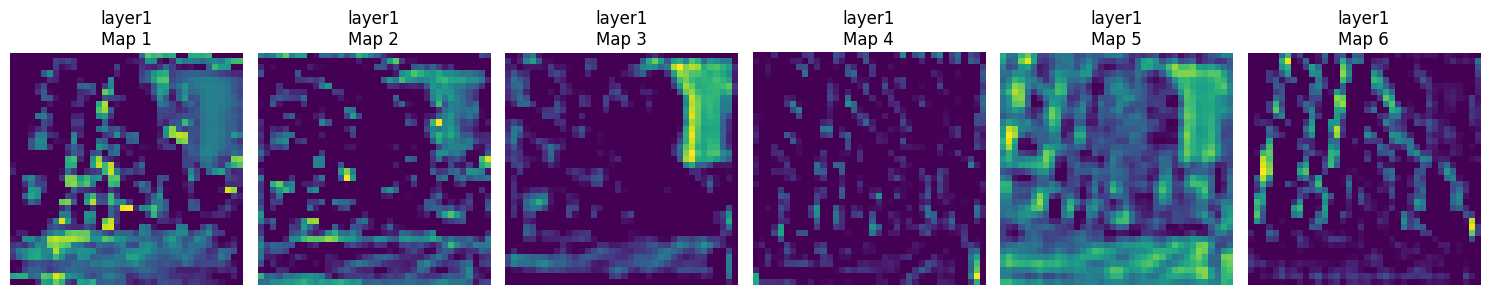

In [53]:
plot_feature_maps(model_finetune_all, test_dataset, device, architecture="resnet", class_names=test_dataset.classes)

#### **Saving all Resnet-18 Models**

In [ ]:
torch.save(model_fc_only.state_dict(), 'ResNet18-IntelFC.pth')
print("ResNet18-IntelFC state dict saved successfully!")

torch.save(model_finetune_last.state_dict(), 'ResNet18-IntelLL.pth')
print("ResNet18-IntelLL state dict saved successfully!")

torch.save(model_finetune_all.state_dict(), 'ResNet18-IntelFineAll.pth')
print("ResNet18-IntelFineAll state dict saved successfully!")

ResNet18-IntelFC state dict saved successfully!
ResNet18-IntelLL state dict saved successfully!
ResNet18-IntelFineAll state dict saved successfully!


 before going into results lets discuss something:
 - fine-tuning the entire pretrained model on a small dataset often causes overfitting. The model, which has millions or billions of parameters, has enough complexity to simply memorize the limited training examples rather than learning generalizable patterns
 - So, Finetuning a whole pretrained model on a small data leads to poor performance on new, unseen data. Therefore, the last model's val accuracy is 5% less than the train acc alongside having a nearly 5% less train accuracy than the freeze last layer model

#### The 2nd ResNet Model achieved a Train Acc of 98.12% shows that unfreezing the last layers allowed the model to fit the data much better even though the generalization gap is 6.17%, the trade-off was worth it because the model's "peak" understanding of the images was significantly higher than the others with a val accuracy of ~ 92%.
- Additionally it yielded the most decent confusion matrix out of the 3!

#### In this deep learning task, I implemented **three neural network architectures** with increasing complexity to evaluate their effectiveness on the Intel Image Classification problem. To align with the golden standards, i have started with a sanity check by overfitting a small subset of the data to see the results. Then, I have trained and MLP on the Intel data and yielded an average results, almost 55% accuracy. The second model was a Convolutional Neural Netwok and it yielded an accuracies of 85% - 75% depends on which model. The Last model was a pretrained model ResNet-18 and it yielded a training accuracies of 90%-98% and 88%-93% val accuracy with the freeze last layer model taking the lead with train acc of ~ 98.2% and 92% val acc.
- Overall, the results confirm that CNNs outperform MLPs for image tasks, and transfer learning provides the highest performance when working with moderate-sized datasets.

##### **Reproducibility** was ensured by fixing random seeds and saving trained model weights for any usage in the future. This experiment demonstrates the importance of progressive model designing and a proper evaluation pipeline for any deep nn projects or tasks


---

### Final Model Prformance comparison

| Model | Test Loss | Test Accuracy |
| --- | --- | --- |
| **MLP** | 1.2020 | **55.10%** |
| **CNN without dropouts** | 0.5423 | **82.23%** |
| **CNN with dropouts** | 0.4877 | **83.27%** |
| **CNN (droputs, bn, weight decay)** | 0.6542 | **75.37%** |
| **ResNet18 – FC Only** | 0.3260 | **87.80%** |
| **ResNet18 – Finetune Last Layers** | **0.2746** | **91.70%** |
| **ResNet18 – Finetune All** | 0.3130 | **88.83%** |

---
 - with **fine tune last layers** taking the lead

# Thank You
### Delivered by
- Mohamed Abdelmohsen Soliman